In [1]:
import gpflow as gpf 
import numpy as np
import scipy.stats as ss
from tslearn.metrics import dtw

import matplotlib.pyplot as plt 
import tqdm as tqdm
import os

import sys
sys.path.append("../..")

from atmodel import AdaptiveTransferGPR, ConditionalMOGP, SparseCMOGP
from atkernel import TransferKernel, TransferCoregion
from atlikelihood import TransferLikelihood

2026-05-11 12:59:08.422381: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-11 12:59:08.424932: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-11 12:59:08.473502: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-11 12:59:08.474313: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-11 12:59:09.473677: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT

# Data loading
If you want to download some other time range, remove the file volatility_data.npz. The problem is that if you do too many requests to yfinance, it at some point will think you are a bot and stop giving you data. 

In [2]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

def standardize(s, mu=None, std=None):
    if not mu and not std:
        return (s - np.nanmean(s)) / np.nanstd(s)
    else:
        return (s - mu) / std

if not os.path.isfile("volatility_data.npz"):
    amzn = yf.download('AMZN', start='2021-01-01', end='2024-01-01')
    vix = yf.download('^VIX', start='2021-01-01', end='2024-03-01')
    amzn_test = yf.download('AMZN', start='2024-01-01', end='2024-03-01')

    amzn_monthly = amzn['Close'].resample('M').last()
    vix_weekly = vix['Close'].resample('W').last().interpolate("cubicspline")
    amzn_monthly_test = amzn_test['Close'].resample('M').last()

    amzn_monthly_returns = np.nan_to_num(amzn_monthly.values, 0)
    amzn_monthly_test_returns = np.nan_to_num(amzn_monthly_test.values, 0)
    vix_weekly_vals = vix_weekly.values

    Bx = amzn_monthly.index.view("int64").reshape(-1, 1).astype(float)
    Xtest = amzn_monthly_test.index.view("int64").reshape(-1, 1).astype(float)
    Ax = vix_weekly.index.view("int64").reshape(-1, 1).astype(float)
    Xtest = (Xtest - Bx.min()) /(Bx.max() - Bx.min())
    Ax = (Ax - Bx.min()) /(Bx.max() - Bx.min())
    Bx = (Bx - Bx.min()) /(Bx.max() - Bx.min())
    By = standardize(amzn_monthly_returns).reshape(-1, 1)
    Ay = standardize(vix_weekly_vals).reshape(-1, 1)
    ytest = standardize(amzn_monthly_test_returns, mu=np.nanmean(amzn_monthly_returns), std=np.nanstd(amzn_monthly_returns)).reshape(-1, 1)

    X = np.vstack((np.hstack((Ax, np.zeros_like(Ax))), np.hstack((Bx, np.ones_like(Bx)))))
    y = np.vstack((np.hstack((Ay, np.zeros_like(Ay))), np.hstack((By, np.ones_like(By)))))
    Xtest = np.hstack((Xtest, np.ones_like(Xtest)))

    np.savez(file="volatility_data.npz", X=X, y=y, Xtest=Xtest, ytest=ytest)

    print(len(Ax), len(Ay), len(Bx), len(By))
    print(Bx, By)
else:
    data = np.load("volatility_data.npz")
    X = data["X"]
    y = data["y"]
    Xtest = data["Xtest"]
    ytest = data["ytest"]
    Ax = X[X[:,1] == 0]
    Bx = X[X[:,1] == 1] 
    Ay = y[y[:,1] == 0]
    By = y[y[:,1] == 1]
    print(len(Ax) ,len(Bx))

165 36


In [3]:
def plot_gp(x, mu, var, color, label):
    plt.plot(x, mu, color=color, lw=2, label=label)
    plt.fill_between(
        x[:, 0],
        (mu - 2 * np.sqrt(var))[:, 0],
        (mu + 2 * np.sqrt(var))[:, 0],
        color=color,
        alpha=0.4,
    )


def plot(m):
    plt.figure(figsize=(8, 4))
    Xtest = np.linspace(0, 1, 100)[:, None]
    plt.plot(Ax, Ay, "x", color="C0", mew=2)
    mu, var = m.predict_f(np.hstack((Xtest, np.zeros_like(Xtest))))
    plot_gp(Xtest, mu, var, "C0", "Y1")

    plt.plot(Bx, By, "x",color="C1", mew=2)
    mu, var = m.predict_f(np.hstack((Xtest, np.ones_like(Xtest))))
    plot_gp(Xtest, mu, var, "C1", "Y2")
    try:
        ivs = m.inducing_variable.Z.numpy() 
        plt.scatter(ivs, np.zeros_like(ivs)+2, marker="|", c=m.inducing_indices, cmap="plasma")
        plt.colorbar()
    except AttributeError:
        pass
    plt.xlim([0, max(X[:,0])])
    plt.legend()
    return mu


def optimize(m):
    opt = gpf.optimizers.Scipy()
    res = opt.minimize(m.training_loss, m.trainable_variables, track_loss_history=True, options={"disp": 50})
    plt.plot(res["loss_history"])
    plt.show()
 

# Plot data

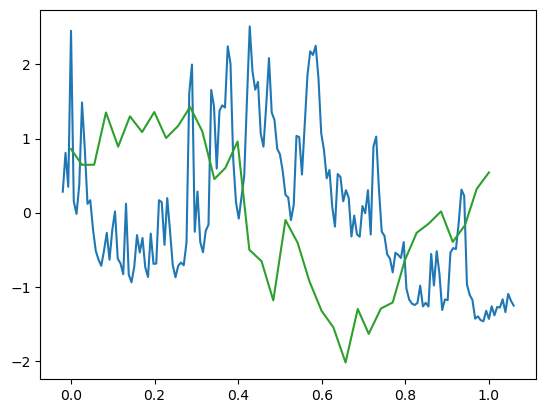

In [4]:
plt.plot(Ax, Ay)
plt.plot(Bx, By)

# Conditional MOGP

╒════════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤═════════╕
│ name                                               │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │ value   │
╞════════════════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪═════════╡
│ ConditionalMOGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.0     │
├────────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼─────────┤
│ ConditionalMOGP.kernel.kernels[0].lengthscales     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.0     │
├────────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼─────────┤
│ ConditionalMOGP.ke

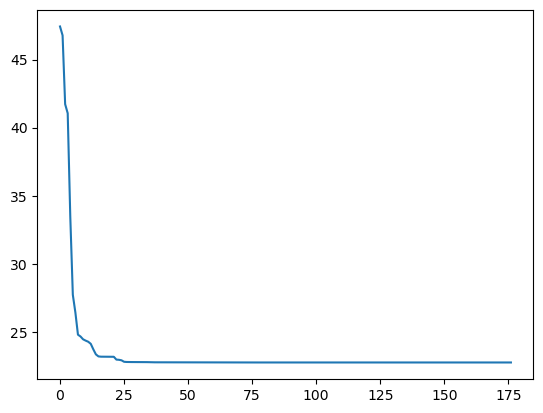

╒════════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤═════════════════════════╕
│ name                                               │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │ value                   │
╞════════════════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪═════════════════════════╡
│ ConditionalMOGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 0.002982923404796977    │
├────────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼─────────────────────────┤
│ ConditionalMOGP.kernel.kernels[0].lengthscales     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 0.23889963856487656     │
├────────────────────────────────────────────────────┼──────────

In [24]:
output_dim = 2  # Number of outputs
rank = 1  # Rank of W

# Base kernel
k = gpf.kernels.RBF(active_dims=[0])
# Coregion kernel
coreg = gpf.kernels.Coregion(
    output_dim=output_dim, rank=rank, active_dims=[1]
)
coreg2 = gpf.kernels.Coregion(
    output_dim=output_dim, rank=rank, active_dims=[1]
)

# Initialize equal amounts of IVs for both datasets.
ivs = np.linspace(0, max(X[:,0]), 20).reshape(-1, 1)
iv_ind = np.concatenate((np.zeros((int(len(ivs)/2),1)), np.ones((int(len(ivs)/2),1))))
shuffle = np.random.permutation(np.arange(len(ivs)))
ivs = ivs[shuffle]
ivs = np.hstack((ivs, iv_ind))

kern = k * coreg
m = ConditionalMOGP((X, y), kernel=kern, likelihood=TransferLikelihood(source=gpf.likelihoods.Gaussian(), target=gpf.likelihoods.Gaussian()))

gpf.utilities.print_summary(m)
optimize(m)
gpf.utilities.print_summary(m)

TensorShape([201, 100])
TensorShape([201, 100])


/tmp/ipykernel_14678/2485261010.py:5: RuntimeWarning: invalid value encountered in sqrt
  (mu - 2 * np.sqrt(var))[:, 0],
/tmp/ipykernel_14678/2485261010.py:6: RuntimeWarning: invalid value encountered in sqrt
  (mu + 2 * np.sqrt(var))[:, 0],


<tf.Tensor: shape=(100, 1), dtype=float64, numpy=
array([[ 6.55129108e-01],
       [ 6.98743893e-01],
       [ 7.42585835e-01],
       [ 7.86416556e-01],
       [ 8.29983252e-01],
       [ 8.73019995e-01],
       [ 9.15249242e-01],
       [ 9.56383518e-01],
       [ 9.96127271e-01],
       [ 1.03417890e+00],
       [ 1.07023291e+00],
       [ 1.10398221e+00],
       [ 1.13512055e+00],
       [ 1.16334495e+00],
       [ 1.18835833e+00],
       [ 1.20987212e+00],
       [ 1.22760884e+00],
       [ 1.24130478e+00],
       [ 1.25071257e+00],
       [ 1.25560376e+00],
       [ 1.25577123e+00],
       [ 1.25103159e+00],
       [ 1.24122740e+00],
       [ 1.22622923e+00],
       [ 1.20593753e+00],
       [ 1.18028438e+00],
       [ 1.14923493e+00],
       [ 1.11278863e+00],
       [ 1.07098022e+00],
       [ 1.02388046e+00],
       [ 9.71596580e-01],
       [ 9.14272372e-01],
       [ 8.52088094e-01],
       [ 7.85260006e-01],
       [ 7.14039609e-01],
       [ 6.38712599e-01],
       [ 5.595

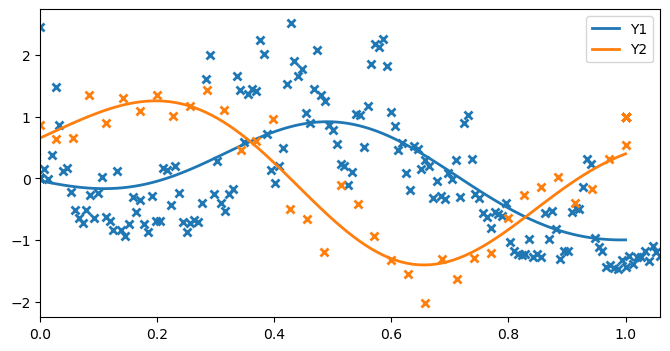

In [25]:
plot(m)

# Sparse CMOGP

You'll see results vary quite a lot dependent on (final) inducing point placement. If they happen to end up in the test data area, we do pretty well, else, we do not.

╒════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤═════════════════╕
│ name                                           │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │ value           │
╞════════════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪═════════════════╡
│ SparseCMOGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.0             │
├────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼─────────────────┤
│ SparseCMOGP.kernel.kernels[0].lengthscales     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.0             │
├────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼───────────

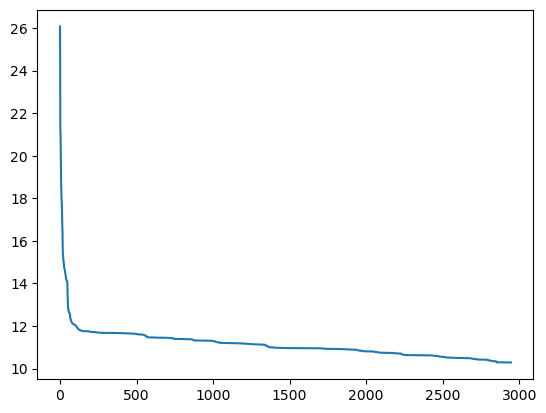

╒════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤════════════════════════╕
│ name                                           │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │ value                  │
╞════════════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪════════════════════════╡
│ SparseCMOGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.31308                │
├────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼────────────────────────┤
│ SparseCMOGP.kernel.kernels[0].lengthscales     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 0.1770919764161829     │
├────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼───

In [30]:
output_dim = 2  # Number of outputs
rank = 1  # Rank of W

# Base kernel
k = gpf.kernels.RBF(active_dims=[0])
k2 = gpf.kernels.Matern32(active_dims=[0])
# Coregion kernel
coreg = gpf.kernels.Coregion(
    output_dim=output_dim, rank=rank, active_dims=[1]
)
coreg2 = gpf.kernels.Coregion(
    output_dim=output_dim, rank=rank, active_dims=[1]
)
ivs = np.linspace(0, max(X[:,0]), 20).reshape(-1, 1)
iv_ind = np.concatenate((np.zeros((int(len(ivs)/2),1)), np.ones((int(len(ivs)/2),1))))
shuffle = np.random.permutation(np.arange(len(ivs)))
ivs = ivs[shuffle]
ivs = np.hstack((ivs, iv_ind))
kern = k2 * coreg
m = SparseCMOGP((X, y), exact_target=False, jitter=1e-5, kernel=kern, inducing_variable=ivs, likelihood=TransferLikelihood(source=gpf.likelihoods.Gaussian(), target=gpf.likelihoods.Gaussian()))
#gpf.set_trainable(m.inducing_variable.Z, False)
#gpf.set_trainable(m.likelihood.source.variance, False)

gpf.utilities.print_summary(m)
optimize(m)
gpf.utilities.print_summary(m)

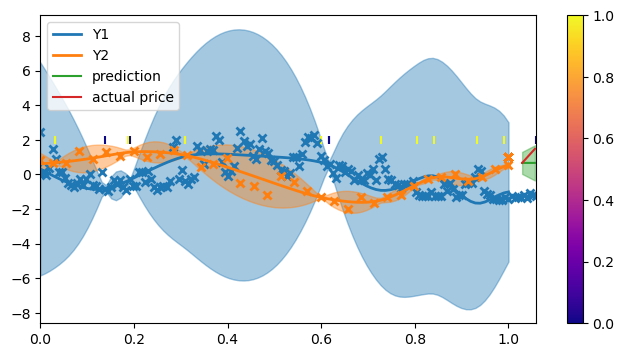

0.3291257177848203


In [32]:
plot(m)
mu, var = m.predict_f(Xtest)
plt.plot(Xtest[:,0], mu, label="prediction", color="C2")
plt.plot(Xtest[:,0], ytest, label="actual price", color="C3")

plt.fill_between(
        Xtest[:, 0],
        (mu - 2 * np.sqrt(var))[:, 0],
        (mu + 2 * np.sqrt(var))[:, 0],
        color="C2",
        alpha=0.4,
    )
plt.legend()
plt.show()
print(np.mean((mu - ytest)**2))


# Sparse VGP
This is technically not valid to do, since there is no way in GPFlow to fix the indices of the Coregion kernel while optimizing a sparse model. 

In [ ]:
# This likelihood switches between Gaussian noise with different variances for each f_i:
k = gpf.kernels.Matern32(active_dims=[0])
k2 = gpf.kernels.Matern32(active_dims=[0])
# Coregion kernel
coreg = gpf.kernels.Coregion(
    output_dim=output_dim, rank=rank, active_dims=[1]
)
coreg2 = gpf.kernels.Coregion(
    output_dim=output_dim, rank=rank, active_dims=[1]
)
ivs = np.linspace(0, max(X[:,0]), 20).reshape(-1, 1)
iv_ind = np.concatenate((np.zeros((int(len(ivs)/2),1)), np.ones((int(len(ivs)/2),1))))
shuffle = np.random.permutation(np.arange(len(ivs)))
ivs = ivs[shuffle]
ivs = np.hstack((ivs, iv_ind))
kern = k * coreg

lik = gpf.likelihoods.SwitchedLikelihood(
    [gpf.likelihoods.Gaussian(), gpf.likelihoods.Gaussian()]
)
# now build the GP model as normal
m = gpf.models.SVGP(kernel=kern, likelihood=lik, num_data=len(X), inducing_variable=ivs)

# fit the covariance function parameters
gpf.optimizers.Scipy().minimize(
    m.training_loss_closure((X, y)),
    m.trainable_variables,
    method="L-BFGS-B",
)
gpf.utilities.print_summary(m)

2026-05-11 13:09:41.787130: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/diag_part_grad/diag/diag_part/k' with dtype int32
	 [[{{node gradients/diag_part_grad/diag/diag_part/k}}]]
2026-05-11 13:09:41.879501: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2_grad/ReverseV2/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2/axis' with dtype int32 and shape [1]
	 [[{{node gradients/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2_grad

<Parameter: name=identity, dtype=float64, shape=[20, 2], fn="identity", numpy=
array([[0.67395939, 0.        ],
       [0.26740586, 0.        ],
       [0.92457041, 0.        ],
       [0.82362368, 0.        ],
       [0.17544638, 0.        ],
       [0.5270055 , 0.        ],
       [0.01069801, 0.        ],
       [0.08902955, 0.        ],
       [1.01381744, 0.        ],
       [0.37129879, 0.        ],
       [0.16515003, 1.        ],
       [0.84292888, 1.        ],
       [0.5929661 , 1.        ],
       [0.02560035, 1.        ],
       [0.73430075, 1.        ],
       [0.9706634 , 1.        ],
       [0.39397465, 1.        ],
       [0.52363628, 1.        ],
       [0.45651213, 1.        ],
       [0.28860179, 1.        ]])>


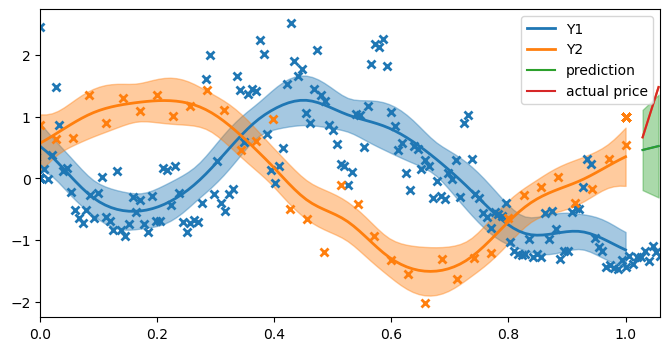

0.4776884833603378


In [ ]:
plot(m)
print(m.inducing_variable.Z)
mu, var = m.predict_f(Xtest)
plt.plot(Xtest[:,0], mu)
plt.plot(Xtest[:,0], ytest)
plt.plot(Xtest[:,0], mu, label="prediction")
plt.plot(Xtest[:,0], ytest, label="actual price")
plt.fill_between(
        Xtest[:, 0],
        (mu - 2 * np.sqrt(var))[:, 0],
        (mu + 2 * np.sqrt(var))[:, 0],
        color="C2",
        alpha=0.4,
    )
plt.legend()
plt.show()
print(np.mean((mu - ytest)**2))